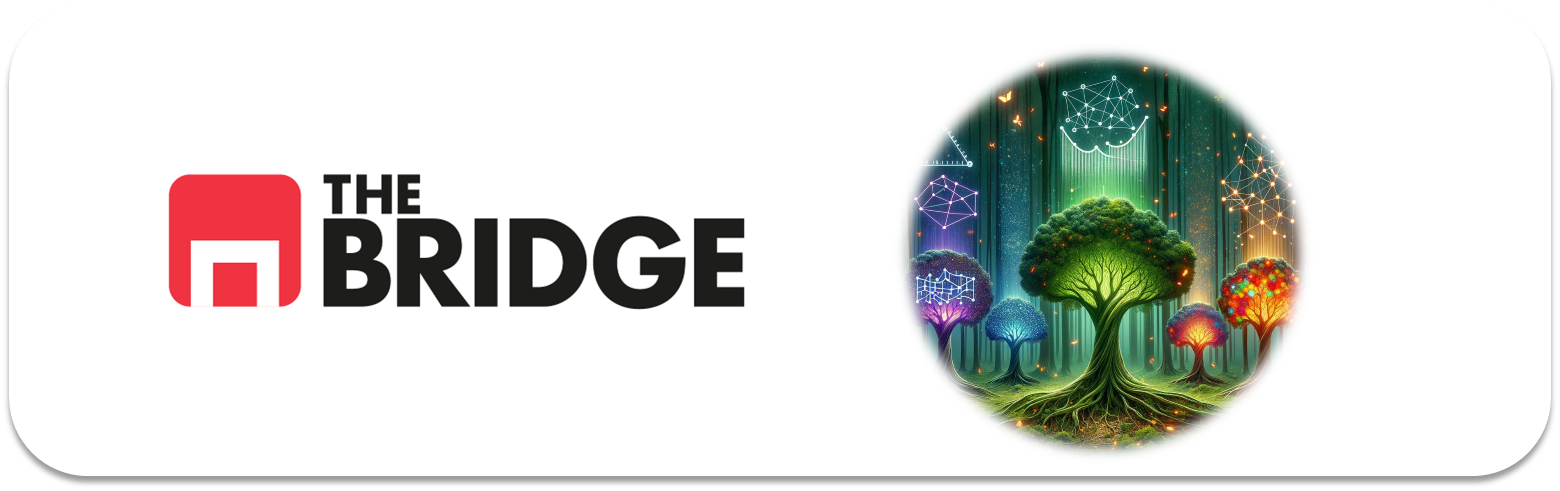

## PRACTICA OBLIGATORIA: **Ensembles: Bagging y Boosting**

* La práctica obligatoria de esta unidad consiste en un único ejercicio de obtención del mejor modelo para la resolución de un problema de clasificación sobre diabetes en la india. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [31]:
# Como no sabemos lo que vamos a utilizar, importamos todo
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import ElasticNet
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error, \
                            ConfusionMatrixDisplay, classification_report, accuracy_score
from sklearn.model_selection import cross_val_score, GridSearchCV, RandomizedSearchCV, train_test_split
from sklearn.preprocessing import StandardScaler

In [32]:
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from xgboost import XGBRegressor, XGBClassifier
from lightgbm import LGBMRegressor, LGBMClassifier

### Descripción del dataset

El dataset de los Pima Indians Diabetes contiene datos de un grupo de mujeres de al menos 21 años de edad de ascendencia india Pima que viven cerca de Phoenix, Arizona, EE. UU. Las características del dataset incluyen varios predictores médicos y un objetivo que indica si la paciente desarrolló diabetes dentro de cinco años.

### Características del Dataset

Las variables incluidas en el dataset son:

1. **Número de Embarazos**: Cantidad de veces embarazada.
2. **Concentración de Glucosa en Plasma**: Concentración de glucosa en plasma a 2 horas en una prueba de tolerancia oral a la glucosa.
3. **Presión Arterial Diastólica**: Presión arterial diastólica (mm Hg).
4. **Grosor del Pliegue Cutáneo del Tríceps**: Grosor del pliegue cutáneo del tríceps (mm).
5. **Insulina en Suero**: Insulina en suero a 2 horas (mu U/ml).
6. **Índice de Masa Corporal**: Peso en kg/(altura en m)^2.
7. **Función del Pedigree de Diabetes**: Una función que representa la predisposición genética a la diabetes.
8. **Edad**: Edad en años.
9. **Variable Objetivo**: Indica si la paciente desarrolló diabetes (1) o no (0).

### Carga de datos

El dataset lo puedes encontrar en la siguiente url y a continuación se proporciona una lista de nombres sugeridos para las columnas:


In [33]:
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"

names = ['preg', 'plas', 'pres', 'skin', 'test', 'mass', 'pedi', 'age', 'class']

### Enunciado

Construye el mejor modelo que puedas para predecir a partir de los datos de entrada si una mujer de la tribu Pima desarrollará diabetes. Para ello obtén al menoss tres modelos a partir de tecnologías de bagging y boosting (al menos uno de cada), compáralos sin utilizar el test y selecciona uno de ellos como el mejor (justificándolo). Termina el ejercicio probando el modelo seleccionado y con sus hiperparámetros optimizados contra un dataset de test que deberás haber reservado con anterioridad.

In [34]:
df_diabetes = pd.read_csv(url, names=names)

In [35]:
df_diabetes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   preg    768 non-null    int64  
 1   plas    768 non-null    int64  
 2   pres    768 non-null    int64  
 3   skin    768 non-null    int64  
 4   test    768 non-null    int64  
 5   mass    768 non-null    float64
 6   pedi    768 non-null    float64
 7   age     768 non-null    int64  
 8   class   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [36]:
target = "class"
features = names.copy()
features.remove(target)

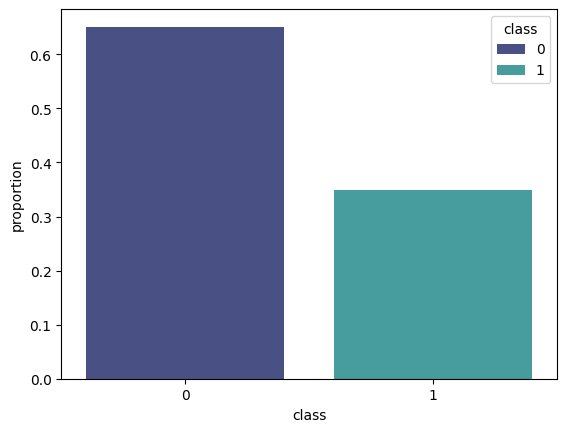

In [37]:
sns.countplot(df_diabetes, x=target, hue=target, palette="mako", stat="proportion");

In [38]:
df_diabetes[target].value_counts(True)

class
0    0.651042
1    0.348958
Name: proportion, dtype: float64

## 2. Split Train-Test

In [39]:
rand = 51
train_set, test_set = train_test_split(df_diabetes, test_size = 0.20, random_state=rand)
X_train = train_set[features]
y_train = train_set[target]
X_test = test_set[features]
y_test = test_set[target]

## 3. Mini EDA

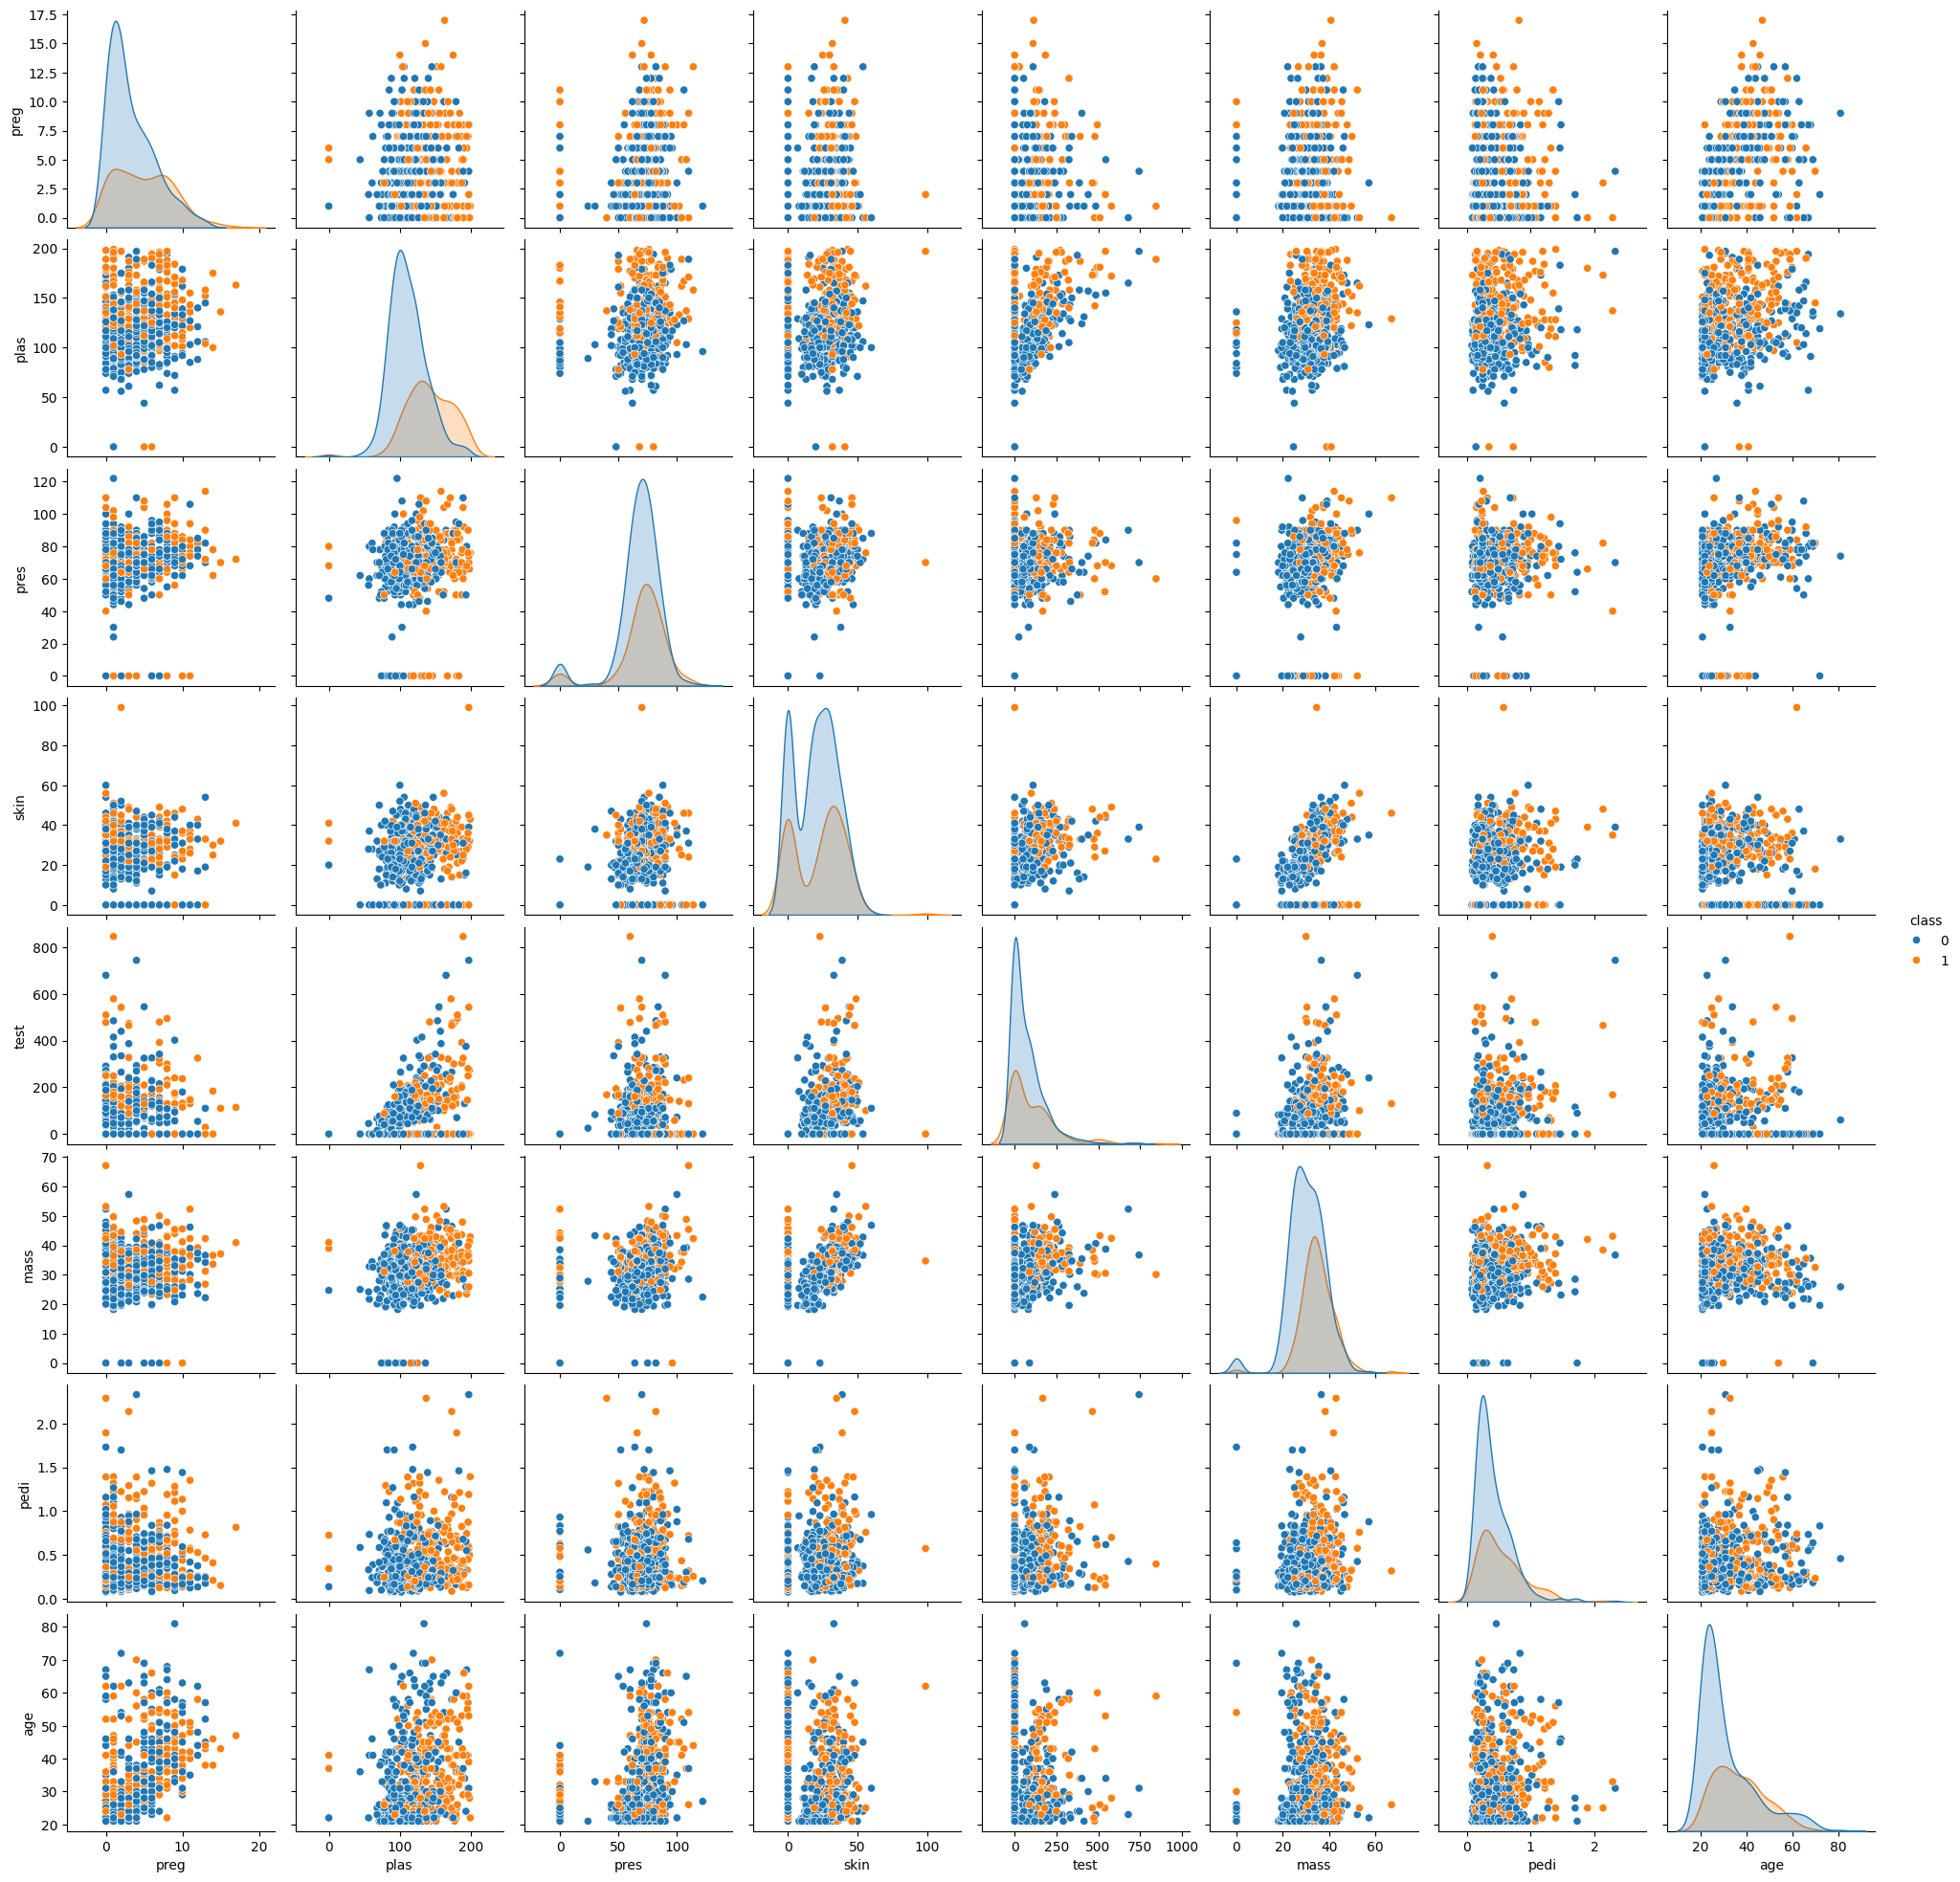

In [40]:
sns.pairplot(train_set, hue=target)

In [41]:
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns= features)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns = features)

## 4. Entrenamiento de modelos
### Clasificadores:

In [42]:
classifier_names = ["Logistic Regression", "DecisionTree Clf.","Random Forest Clf.","XGBoost Clf.","LightGBM Clf."]
lr_clf = LogisticRegression(max_iter = 10000)
tree_clf = DecisionTreeClassifier(random_state= rand)
rf_clf = RandomForestClassifier(random_state= rand)
xgb_clf = XGBClassifier(random_state= rand)
lgbm_clf = LGBMClassifier(random_state= rand, verbose = -100)

classifier_set = [lr_clf, tree_clf, rf_clf, xgb_clf, lgbm_clf]

In [43]:
metricas_cv_clf = {}
valores_clf = []
for nombre, clasificador in zip(classifier_names, classifier_set):
    print(clasificador)
    if nombre != "Logistic Regression":
        metricas_cv_clf[nombre] = cross_val_score(clasificador, X_train, y_train, cv = 3, scoring = "accuracy")
    else:
        metricas_cv_clf[nombre] = cross_val_score(clasificador, X_train_scaled, y_train, cv = 5, scoring = "accuracy")
    valores_clf.append(np.mean(metricas_cv_clf[nombre]))
ganador_clf = list(metricas_cv_clf.keys())[np.argmax(valores_clf)]

LogisticRegression(max_iter=10000)
DecisionTreeClassifier(random_state=51)
RandomForestClassifier(random_state=51)
XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)
LGBMClassifier(random_state=51, verbose=-100)


In [44]:
for model_name, valores_clf in metricas_cv_clf.items():
    print(f"Model <{model_name}>, Accuracy_CV: {np.mean(valores_clf)}")
print(f"El ganador es {ganador_clf}")

Model <Logistic Regression>, Accuracy_CV: 0.7588564574170332
Model <DecisionTree Clf.>, Accuracy_CV: 0.6758568468037621
Model <Random Forest Clf.>, Accuracy_CV: 0.7622270046229874
Model <XGBoost Clf.>, Accuracy_CV: 0.7540889526542324
Model <LightGBM Clf.>, Accuracy_CV: 0.7393910409692332
El ganador es Random Forest Clf.


El peor modelo es el modelo de árbol de decisión base, lo que es de esperar, dado que es es menos optimizado.

Dentro de los modelos de boosting, LightGBM tiene un mayor accuracy que XGBoost, pero la diferencia no es muy grande. Dada la gran cantidad de datos numéricos, la estrategia de binning de LightGBM resulta en un mejor modelo que el XGBoost.

Finalmente, el modelo de bagging RandomForest tiene el mayor accuracy, con la regresión logística siendo la segunda mejor. El resultado no es muy bueno para ninguna, pero el mejor modelo es el Random Forest Classifier.

### Regresores:

In [45]:
regressor_names = ["Regresion Lineal","DecisionTree Reg.","Random Forest Reg.","XGBoost Reg.","LightGBM Reg."]
lr_reg = LinearRegression()
tree_reg = DecisionTreeRegressor(random_state= 42)
rf_reg = RandomForestRegressor(random_state= 42)
xgb_reg = XGBRegressor(random_state = 42)
lgb_reg = LGBMRegressor(random_state= 42, verbose = -100)

regressor_set = [lr_reg, tree_reg, rf_reg, xgb_reg, lgb_reg]


In [46]:
metricas_cv_reg = {}
valores_reg = []
for nombre, regresor in zip(regressor_names, regressor_set):
    print(regresor)
    if nombre == "Regresion Lineal":
        metricas_cv_reg[nombre] = cross_val_score(regresor, X_train_scaled, y_train, cv = 5, scoring = "neg_mean_squared_error")
    else:
        metricas_cv_reg[nombre] = cross_val_score(regresor, X_train, y_train, cv = 5, scoring = "neg_mean_squared_error")
    valores_reg.append(np.mean(metricas_cv_reg[nombre]))
ganador_reg = list(metricas_cv_reg.keys())[np.argmax(valores_reg)]

LinearRegression()
DecisionTreeRegressor(random_state=42)
RandomForestRegressor(random_state=42)
XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)
LGBMRegressor(random_state=42, verbose=-100)


In [47]:
for model_name, valores_reg in metricas_cv_reg.items():
    print(f"Model <{model_name}>, RMSE_CV: {np.sqrt(-np.mean(valores_reg))}")
print(f"El ganador es {ganador_reg}")

Model <Regresion Lineal>, RMSE_CV: 0.40867107960967347
Model <DecisionTree Reg.>, RMSE_CV: 0.541543496796977
Model <Random Forest Reg.>, RMSE_CV: 0.405888640431454
Model <XGBoost Reg.>, RMSE_CV: 0.4382641726072
Model <LightGBM Reg.>, RMSE_CV: 0.42647813981064975
El ganador es Random Forest Reg.


Ocurre lo mismo con los regresores, donde RandomForest tiene el menor error cuadrático medio.

Entre los modelos básicos de regresión, Decision Tree es mejor que la regresión lineal estándar, y las diferencias entre LightGBM y XGBoost son poco notables.

## 5. Optimización de hiperparámetros
### Clasificador Random Forest

In [48]:
params_grid = {
    "n_estimators": [100,200, 400],
    "max_depth": [2,4,6],
    "min_samples_leaf": [20,30,50],
    "max_features": [2,3,4,5],
    "max_samples": [0.2,0.3,0.6],
    "class_weight": ["balanced"]
}

rf_grid = GridSearchCV(rf_clf,
                       param_grid= params_grid,
                       cv = 5,
                       scoring = "recall",
                       n_jobs = -1)

rf_grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=51)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'class_weight': ['balanced'], 'max_depth': [2, 4, ...], 'max_features': [2, 3, ...], 'max_samples': [0.2, 0.3, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'recall'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"ver

In [49]:
rf_grid.best_score_

np.float64(0.8013289036544851)

In [50]:
rf_grid.best_params_

{'class_weight': 'balanced',
 'max_depth': 4,
 'max_features': 2,
 'max_samples': 0.6,
 'min_samples_leaf': 20,
 'n_estimators': 200}

              precision    recall  f1-score   support

           0       0.84      0.76      0.80        97
           1       0.65      0.75      0.70        57

    accuracy                           0.76       154
   macro avg       0.75      0.76      0.75       154
weighted avg       0.77      0.76      0.76       154



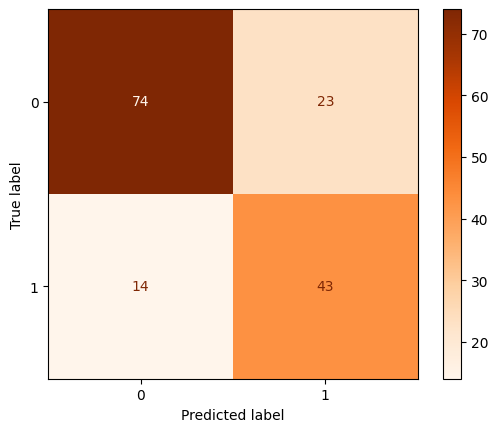

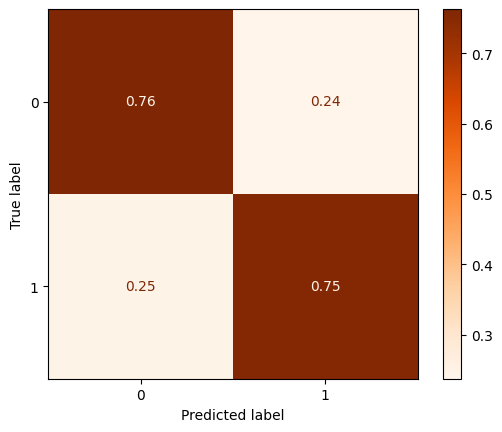

In [51]:
y_pred = rf_grid.best_estimator_.predict(X_test)
print(classification_report(y_test, y_pred))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap="Oranges")
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap="Oranges", normalize="true")

Optimizando para el recall evitamos que haya muchos falsos negativos, que son el error más relevante de cara a la predicción del modelo. Por otro lado, obtenemos resultados en el entrenamiento superiores al obtenido con test, pero estos son bastante uniformes respecto a las predicciones positivas y negativas de diabetes.

### Regresor Random Forest

In [52]:
params_grid = {
    "n_estimators": [100,200, 400],
    "max_depth": [2,4,6],
    "min_samples_leaf": [20,30,50],
    "max_features": ["sqrt","log2",None],
    "max_samples": [0.2,0.3,0.6],
}

rf_grid = GridSearchCV(rf_reg,
                       param_grid= params_grid,
                       cv = 5,
                       scoring = "neg_mean_squared_error",
                       n_jobs = -1)

rf_grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [2, 4, ...], 'max_features': ['sqrt', 'log2', ...], 'max_samples': [0.2, 0.3, ...], 'min_samples_leaf': [20, 30, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support 

In [53]:
np.sqrt(-rf_grid.best_score_)

np.float64(0.3999315045144074)

In [54]:
rf_grid.best_params_

{'max_depth': 6,
 'max_features': None,
 'max_samples': 0.6,
 'min_samples_leaf': 20,
 'n_estimators': 400}

In [55]:
y_pred = rf_grid.best_estimator_.predict(X_test)
print("MAE:", mean_absolute_error(y_test,y_pred))
print("MAPE:", mean_absolute_percentage_error(y_test,y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

MAE: 0.3245128770126036
MAPE: 659857665001272.2
RMSE: 0.3966132743024964


In [56]:
rf_grid.best_estimator_.feature_importances_

array([0.03982021, 0.58788531, 0.01556271, 0.01377524, 0.0127484 ,
       0.15140337, 0.06851647, 0.11028829])

De nuevo, los resultados de entrenamiento y los de comparación con el test son bastante similares, por lo que podemos tener cierta seguridad de que no hay overfitting.

Los valores predecidos se desvían en un ~0.4 respecto de los reales. Considerando que la variable target toma valores de 0 o 1, esta varianza es bastante alta. Ninguno de los modelos es del todo satisfactorio, teniendo en cuenta el objetivo de identificación como el acierto de True 